In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.initializers import RandomNormal
import math
from tqdm import trange


In [2]:
R = 1.2      # 電阻 (kohm)
L = 1.5      # 電感 (H)
C = 0.3      # 電容 (F)
VC_0 = 12.0  # 初始電壓 (V)

t_total = 20.0   # 總模擬時間
t_cutoff = 5.0   # 擬合切斷點

In [3]:
batch_size = 32
epochs = 5000
learning_rate = 0.001

In [4]:
weight_init = RandomNormal()

obs_points = int(t_total * 4)
t_obs_full = np.linspace(0, t_total, obs_points, dtype=np.float32).reshape(-1, 1)

alpha = R / (2 * L)
w0 = np.sqrt(1 / (L * C))
wd = np.sqrt(w0**2 - alpha**2)
i_true_full = (VC_0 / (L * wd)) * np.exp(-alpha * t_obs_full) * np.sin(wd * t_obs_full)
i_obs_full = i_true_full + 0.08 * np.random.normal(size=t_obs_full.shape).astype(np.float32)

mask = t_obs_full.flatten() <= t_cutoff
t_obs_train = t_obs_full[mask]
i_obs_train = i_obs_full[mask]

t_col = np.linspace(0, t_total, 300, dtype=np.float32).reshape(-1, 1)
t_init = np.array([[0.0]], dtype=np.float32)
i_init = np.array([[0.0]], dtype=np.float32)
v_init_val = np.array([[VC_0]], dtype=np.float32)

def build_model():
    input_layer = tf.keras.Input(shape=(1,))
    x = layers.Dense(128, activation='gelu', kernel_initializer=weight_init)(input_layer)
    x = layers.Dense(128, activation='gelu', kernel_initializer=weight_init)(x)
    x = layers.Dense(128, activation='gelu', kernel_initializer=weight_init)(x)
    output_layer = layers.Dense(1, activation='linear', kernel_initializer=weight_init)(x)
    return tf.keras.Model(inputs=input_layer, outputs=output_layer)

model_pinn = build_model()
model_no_pinn = build_model()

opt_pinn = Adam(learning_rate=learning_rate)
opt_no_pinn = Adam(learning_rate=learning_rate)

In [5]:
@tf.function
def step_pinn(t_col, t_init, i_init, v_init_val, t_obs, i_obs):
    with tf.GradientTape() as tape:
        pred_obs = model_pinn(t_obs)
        loss_data = tf.reduce_mean(tf.square(pred_obs - tf.cast(i_obs, tf.float32)))

        pred_0 = model_pinn(t_init)
        loss_init_i = tf.reduce_mean(tf.square(pred_0 - i_init))

        with tf.GradientTape() as tape_v:
            tape_v.watch(t_init)
            pred_v = model_pinn(t_init)
        didt_0 = tape_v.gradient(pred_v, t_init)
        loss_init_v = tf.reduce_mean(tf.square(didt_0 * L - v_init_val))

        with tf.GradientTape() as tape_t2:
            tape_t2.watch(t_col)
            with tf.GradientTape() as tape_t1:
                tape_t1.watch(t_col)
                pred_i = model_pinn(t_col)
            didt = tape_t1.gradient(pred_i, t_col)
        d2idt2 = tape_t2.gradient(didt, t_col)
        residual = d2idt2 + (R/L) * didt + (1/(L * C)) * pred_i
        loss_physics = tf.reduce_mean(tf.square(residual))

        total_loss = 10.0 * loss_data + 1.0 * loss_init_i + 1.0 * loss_init_v + 0.5 * loss_physics

    grads = tape.gradient(total_loss, model_pinn.trainable_variables)
    opt_pinn.apply_gradients(zip(grads, model_pinn.trainable_variables))
    return total_loss

@tf.function
def step_no_pinn(t_obs, i_obs):
    with tf.GradientTape() as tape:
        pred_obs = model_no_pinn(t_obs)
        loss_data = tf.reduce_mean(tf.square(pred_obs - tf.cast(i_obs, tf.float32)))

    grads = tape.gradient(loss_data, model_no_pinn.trainable_variables)
    opt_no_pinn.apply_gradients(zip(grads, model_no_pinn.trainable_variables))
    return loss_data

In [6]:
data_size = len(t_col)
steps_per_epoch = math.ceil(data_size / batch_size)

for epoch in trange(epochs):
    indices = np.random.permutation(data_size)
    t_col_shuffled = t_col[indices]

    for i in range(steps_per_epoch):
        start_idx = i * batch_size
        end_idx = min(start_idx + batch_size, data_size)
        t_batch = t_col_shuffled[start_idx:end_idx]

        step_pinn(t_batch, t_init, i_init, v_init_val, t_obs_train, i_obs_train)
        step_no_pinn(t_obs_train, i_obs_train)

100%|██████████| 5000/5000 [09:16<00:00,  8.99it/s]


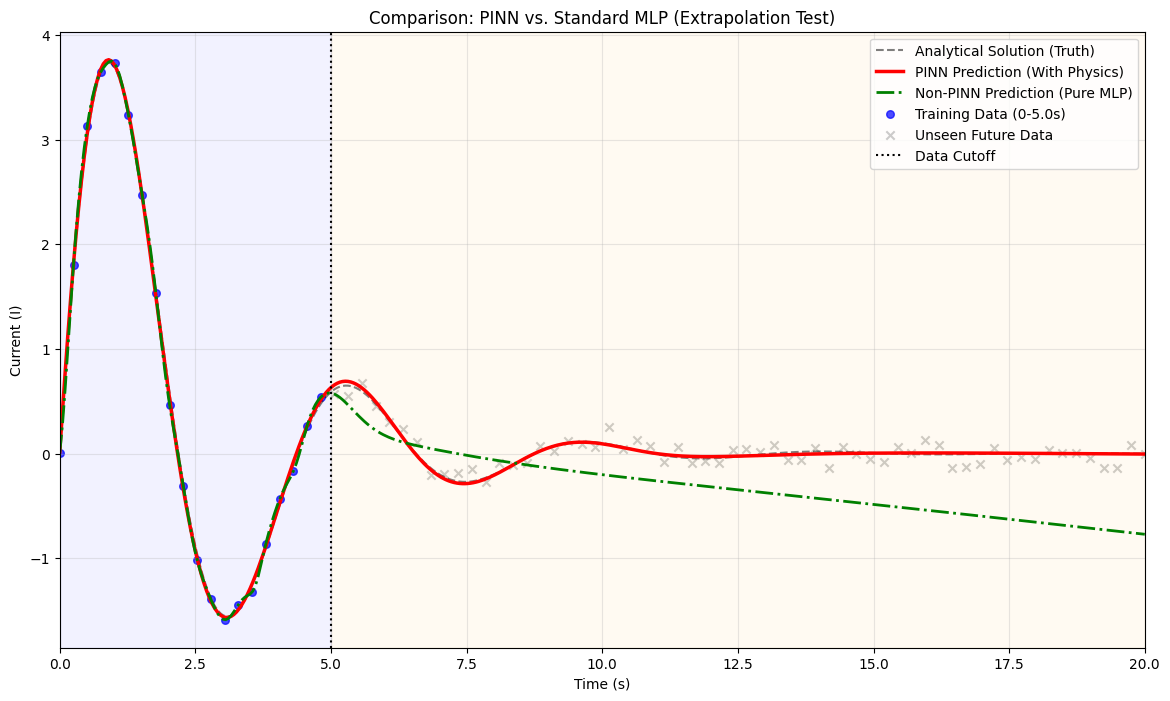

In [7]:
t_test = np.linspace(0, t_total, 400).reshape(-1, 1)
i_pinn = model_pinn(t_test).numpy()
i_no_pinn = model_no_pinn(t_test).numpy()
i_analytical = (VC_0 / (L * wd)) * np.exp(-alpha * t_test) * np.sin(wd * t_test)

plt.figure(figsize=(14, 8))

plt.plot(t_test, i_analytical, 'k--', alpha=0.5, label='Analytical Solution (Truth)')
plt.plot(t_test, i_pinn, 'r-', linewidth=2.5, label='PINN Prediction (With Physics)')
plt.plot(t_test, i_no_pinn, 'g-.', linewidth=2, label='Non-PINN Prediction (Pure MLP)')
plt.scatter(t_obs_train, i_obs_train, color='blue', s=30, alpha=0.7, label=f'Training Data (0-{t_cutoff}s)')
t_obs_test = t_obs_full[~mask]
i_obs_test = i_obs_full[~mask]
plt.scatter(t_obs_test, i_obs_test, color='gray', marker='x', alpha=0.4, label='Unseen Future Data')
plt.axvline(x=t_cutoff, color='black', linestyle=':', label='Data Cutoff')

plt.title('Comparison: PINN vs. Standard MLP (Extrapolation Test)')
plt.xlabel('Time (s)')
plt.ylabel('Current (I)')
plt.xlim(0, t_total)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

plt.axvspan(0, t_cutoff, color='blue', alpha=0.05, label='Fitting Zone')
plt.axvspan(t_cutoff, t_total, color='orange', alpha=0.05, label='Extrapolation Zone')

plt.show()